In [25]:
import xarray as xr
import datetime as dt
import glob
import numpy as np
import pandas as pd
import netCDF4 as nc
import warnings; warnings.simplefilter("ignore")
import matplotlib.pyplot as plt
import matplotlib
import tqdm

In [3]:
def latlon_dist(lat, lon, lats, lons):

        #Calculate great circle distance (Harversine) between a lat lon point (lat, lon) and a list of lat lon
        # points (lats, lons)
                        
        R = 6373.0
                        
        lat1 = np.deg2rad(lat)
        lon1 = np.deg2rad(lon)
        lat2 = np.deg2rad(lats)
        lon2 = np.deg2rad(lons)
                
        dlon = lon2 - lon1
        dlat = lat2 - lat1

        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

        return (R * c)

def get_mask(lon,lat,thresh=0.5):
    #Return lsm for a given domain (with lats=lat and lons=lon)
    lsm,nat_lon,nat_lat = get_lsm()
    lon_ind = np.where((nat_lon >= lon[0]) & (nat_lon <= lon[-1]))[0]
    lat_ind = np.where((nat_lat >= lat[-1]) & (nat_lat <= lat[0]))[0]
    lsm_domain = lsm[(lat_ind[0]):(lat_ind[-1]+1),(lon_ind[0]):(lon_ind[-1]+1)]
    lsm_domain = np.where(lsm_domain > thresh, 1, 0)

    return lsm_domain

def get_lsm():
    #Load the ERA5 land-sea fraction
    lsm_file = nc.Dataset("/g/data/rt52/era5/single-levels/reanalysis/lsm/1979/lsm_era5_oper_sfc_19790101-19790131.nc")
    lsm = np.squeeze(lsm_file.variables["lsm"][0])
    lsm_lon = np.squeeze(lsm_file.variables["longitude"][:])
    lsm_lat = np.squeeze(lsm_file.variables["latitude"][:])
    lsm_file.close()
    return [lsm,lsm_lon,lsm_lat]


def cape_shear_data(var, time, lat, lon, r=0, func=np.max):
    #print("\n",lat, lon, time)
    f = xr.open_dataset(glob.glob("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_"\
                            +time.strftime("%Y%m")+"*.nc")[0])[var].sel({"time":time.replace(minute=0)})

    lats = f.coords.get("lat").values
    lons = f.coords.get("lon").values
    x,y = np.meshgrid(lons,lats)
    mask = get_mask(lons,lats)
    dist_km = (latlon_dist(lat, lon, y, x) )
    if r>0:
        a,b = np.where( (dist_km <= r) & (mask==1) )
        subset = f.isel_points("points",lat=a, lon=b)
        sliced = subset.apply(func)
    else:
        dist_km = np.where(mask==1, dist_km, 9999)
        temp_lat,temp_lon = np.unravel_index(np.nanargmin(dist_km),dist_km.shape)
        sliced = f.isel({"lon":temp_lon, "lat":temp_lat})

    return pd.DataFrame({"var":[np.round(sliced[v].values,1) for v in var]}, index=var)


In [4]:
#DCAPE and LCL

lcl = []
dcape = []
umean = []
cape = []

details = [{"lat":-25.9319, "lon":153.1906, "time":dt.datetime(2006,12,16,8,1)},
            {"lat":-37.6654, "lon":144.8322, "time":dt.datetime(2010,3,6,3,24)},
            {"lat":-27.4034, "lon":151.7413, "time":dt.datetime(2011,10,7,19,21)},
            {"lon": 144.8322, "lat":-37.6654, "time":dt.datetime(2015,2,28,9,24)},
            {"lat":-33.9465, "lon":151.1731, "time":dt.datetime(2016,1,14,4,19)},
            {"lat":-37.9075, "lon":144.1303, "time":dt.datetime(2016,11,21,6,1)},
            {"lat":-38.2332, "lon":143.7924, "time":dt.datetime(2020,1,31,3,42)},
            {"lat":-38.0288, "lon":144.4783, "time":dt.datetime(2020,8,27,7,12)}]           

lcl = [cape_shear_data(["mu_lcl"],d["time"],d["lat"],d["lon"],r=50,func=np.min).values[0,0] for d in details]
dcape = [cape_shear_data(["dcape"],d["time"],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
umean = [cape_shear_data(["Umean06"],d["time"],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
cape = [cape_shear_data(["mu_cape"],d["time"],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
s06 = [cape_shear_data(["s06"],d["time"],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
scp = [cape_shear_data(["scp"],d["time"],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
scp_fixed = [cape_shear_data(["scp_fixed"],d["time"],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
dcp = [cape_shear_data(["dcp"],d["time"],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]

letter = ["a","b","c","d","e","f","g","h"]
df = pd.DataFrame({"lcl":lcl,"dcape":dcape,"umean":umean,"cape":cape,"s06":s06,"scp":scp,"scp_fixed":scp_fixed,"dcp":dcp},index=letter)
df

,lcl,dcape,umean,cape,s06,scp,scp_fixed,dcp
a,343.899994,428.700012,10.500000,2073.100098,21.400000,1.1,1.1,1.2
b,447.600006,672.799988,14.300000,1759.400024,29.500000,3.8,1.8,1.6
c,231.100006,458.600006,10.900000,765.599976,25.200001,1.0,1.1,0.6
d,775.799988,1093.300049,18.400000,320.299988,30.100000,0.0,0.4,0.5
e,1061.599976,1224.599976,11.200000,3111.800049,14.200000,2.7,1.3,2.7
f,1030.300049,1227.599976,18.200001,2625.100098,24.100000,5.1,2.8,4.8
g,2402.199951,1218.599976,18.900000,342.399994,23.900000,0.0,0.1,0.8
h,634.799988,243.000000,31.700001,118.800003,44.799999,0.0,0.2,0.1


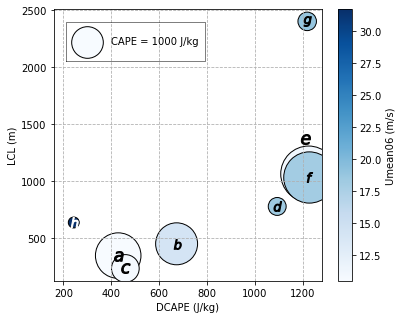

In [5]:
plt.figure(figsize=[6,5])
letter = ["a","b","c","d","e","f","g","h"]
plt.scatter(dcape, lcl, c=umean, cmap=plt.get_cmap("Blues"), edgecolor="k", s=cape)
cb=plt.colorbar(); cb.set_label("Umean06 (m/s)")
for i in np.arange(len(lcl)):
    if letter[i] == "e":
        plt.plot(1210,1370,marker="$"+letter[i]+"$",ls="none",color="k",ms=10,mew=1)
    elif letter[i] == "h":
        plt.plot(dcape[i],lcl[i],marker="$"+letter[i]+"$",ls="none",color="white",ms=10,mew=1)
    else:
        plt.plot(dcape[i],lcl[i],marker="$"+letter[i]+"$",ls="none",color="k",ms=10,mew=1)
plt.xlabel("DCAPE (J/kg)")
plt.ylabel("LCL (m)")
plt.gca().grid(ls="--")

plt.scatter([300], [2225], c=[12], cmap=plt.get_cmap("Blues"), edgecolor="k", s=[1000])
plt.text(400,2225,"CAPE = 1000 J/kg",va="center",ha="left")
plt.plot([210,790,790,210,210],[2050,2050,2400,2400,2050],color="k",lw=0.5)

100%|██████████| 3/3 [01:23<00:00, 27.95s/it]


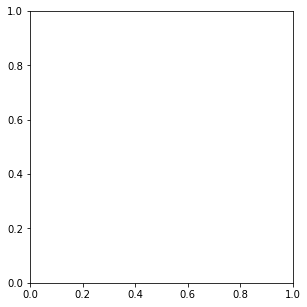

In [14]:
#CAPE and S06

lcl = []
dcape = []
umean = []
cape = []

details_list = [ [\
        {"lat":-37.6654, "lon":144.8322, "time" : [dt.datetime(2009,8,2,15,30)], "rid":"2", "title":"a) Melbourne: 2009-08-02 15:36 UTC"},\
        {"lat":-37.6654, "lon":144.8322, "time" : [dt.datetime(2010,3,6,3,24)], "rid":"2", "title":"b) Melbourne: 2010-03-06 03:24 UTC"},\
        {"lat":-37.6654, "lon":144.8322, "time" : [dt.datetime(2011,12,25,6,44)], "rid":"2", "title":"c) Melbourne: 2011-12-25 06:44 UTC"},\
        {"lat":-37.6654, "lon":144.8322, "time" : [dt.datetime(2012,2,26,9,11)], "rid":"2", "title":"d) Melbourne: 2012-02-26 09:11 UTC"},\
        {"lat":-37.6654, "lon":144.8322, "time" : [dt.datetime(2015,2,28,9,24)], "rid":"2", "title":"e) Melbourne: 2015-02-28 09:24 UTC"},\
        {"lat":-37.9075, "lon":144.1303, "time" : [dt.datetime(2016,11,21,6,1)], "rid":"2", "title":"f) Melbourne: 2016-11-21 06:01 UTC" },\
        {"lat":-38.2332, "lon":143.7924, "time" : [dt.datetime(2020,1,31,3,42)], "rid":"2", "title":"g) Cressy: 2020-01-31 03:42 UTC"},\
        {"lat":-37.5127, "lon":143.7911, "time" : [dt.datetime(2020,5,19,14,27)], "rid":"2", "title":"h) Ballarat: 2020-05-19 14:27 UTC" },\
        {"lat":-38.0288, "lon":144.4783, "time" : [dt.datetime(2020,8,27,7,12)], "rid":"2", "title":"i) Melbourne: 2020-08-27 07:12 UTC"},\
       ], [\
        {"lat":-30.3107, "lon":153.1187, "time" : [dt.datetime(2011,3,1,8,32)], "rid":"28", "title":"a) Coffs Harbour: 2011-03-01 8:36 UTC"},\
        {"lat":-30.3107, "lon":153.1187, "time" : [dt.datetime(2012,2,12,10,12)], "rid":"28", "title":"b) Coffs Harbour: 2012-02-12 10:12 UTC"},\
        {"lat":-34.1407, "lon":151.1185, "time" : [dt.datetime(2014,10,14,9,55)], "rid":"71", "title":"c) Sydney (ECL): 2014-10-14 09:10 UTC"},\
        {"lat":-34.1407, "lon":151.1185, "time" : [dt.datetime(2015,3,1,4,19)], "rid":"71", "title":"d) Sydney: 2015-03-01 04:22 UTC"},\
        {"lat":-33.2814, "lon":151.5766, "time" : [dt.datetime(2015,4,20,18,42)], "rid":"4", "title":"e) Williamtown (ECL): 2015-04-20 18:44 UTC"},\
        {"lat":-34.0039, "lon":151.2111, "time" : [dt.datetime(2015,12,16,1,55)], "rid":"71", "title":"f) Sydney: 2015-12-16 01:58 UTC"},\
        {"lat":-33.9465, "lon":151.1731, "time" : [dt.datetime(2016,1,14,4,19)], "rid":"71", "title":"g) Sydney: 2016-01-14 04:19 UTC"},\
        {"lat":-33.2814, "lon":151.5766, "time" : [dt.datetime(2016,6,4,12,8)], "rid":"71", "title":"h) Sydney: 2016-06-04 12:08 UTC"},\
        {"lat":-35.1583, "lon":147.4575, "time" : [dt.datetime(2017,3,27,7,0)], "rid":"55", "title":"i) Wagga Wagga: 2017-03-27 07:07 UTC"},\
       ], [\
        {"lat":-26.4139, "lon":146.2558, "time" : [dt.datetime(2005,1,22,5,51)], "rid":"38", "title":"a) Charleville: 2005-01-22 05:58 UTC"},\
        {"lat":-25.9319, "lon":153.1906, "time" : [dt.datetime(2006,12,16,8,1)], "rid":"8", "title":"b) Double Island Point: 2006-12-16 08:01 UTC"},\
        {"lat":-27.6297, "lon":152.7111, "time" : [dt.datetime(2011,1,18,5,4)], "rid":"66", "title":"c) Amberly: 2011-01-18 05:05 UTC"},\
        {"lat":-27.4034, "lon":151.7413, "time" : [dt.datetime(2011,10,7,19,29)], "rid":"50", "title":"d) Oakey: 2011-10-07 19:21 UTC"},\
        {"lat":-27.4034, "lon":151.7413, "time" : [dt.datetime(2013,10,18,4,1)], "rid":"50", "title":"e) Oakey: 2013-10-18 04:05 UTC"},\
        {"lat":-27.4034, "lon":151.7413, "time" : [dt.datetime(2014,9,25,4,39)], "rid":"50", "title":"f) Oakey: 2014-09-25 04:39 UTC"},\
        {"lat":-27.5716, "lon":153.0071, "time" : [dt.datetime(2014,11,27,6,30)], "rid":"66", "title":"g) Archerfield: 2014-11-27 06:29 UTC"},\
        {"lat":-27.6297, "lon":152.7111, "time" : [dt.datetime(2016,12,18,4,14)], "rid":"66", "title":"h) Amberly: 2016-12-18 04:14 UTC"},\
        {"lat":-27.4034, "lon":151.7413, "time" : [dt.datetime(2018,2,13,7,1)], "rid":"50", "title":"i) Oakey: 2018-02-13 07:05 UTC"},\
       ]   ]
           
plt.figure(figsize=[16,5])
cnt=1
df_list = []
for details in tqdm.tqdm(details_list):
    plt.subplot(1,3,cnt)
    lcl = [cape_shear_data(["mu_lcl"],d["time"][0],d["lat"],d["lon"],r=50,func=np.min).values[0,0] for d in details]
    dcape = [cape_shear_data(["dcape"],d["time"][0],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
    umean = [cape_shear_data(["Umean06"],d["time"][0],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
    cape = [cape_shear_data(["mu_cape"],d["time"][0],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
    s06 = [cape_shear_data(["s06"],d["time"][0],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
    scp = [cape_shear_data(["scp"],d["time"][0],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
    scp_fixed = [cape_shear_data(["scp_fixed"],d["time"][0],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
    dcp = [cape_shear_data(["dcp"],d["time"][0],d["lat"],d["lon"],r=50,func=np.max).values[0,0] for d in details]
    df_list.append(pd.DataFrame({"lcl":lcl,"dcape":dcape,"umean":umean,"cape":cape,"s06":s06,"scp":scp,"scp_fixed":scp_fixed,"dcp":dcp},index=letter))
    

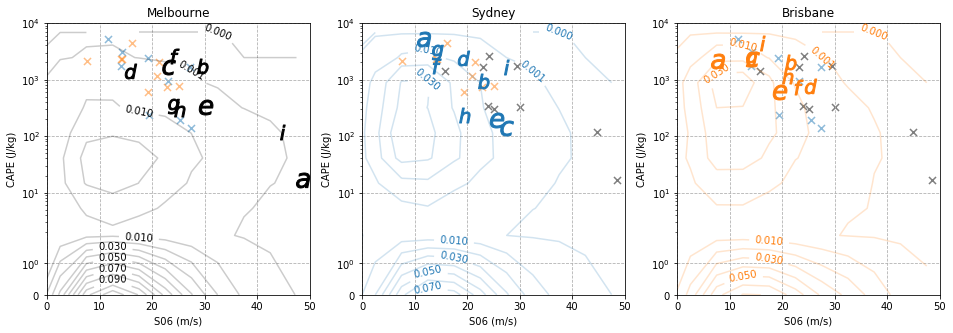

In [229]:
plt.figure(figsize=[16,5])
cnt=1
letter = ["a","b","c","d","e","f","g","h","i"]
letter_cols = ["k","tab:blue","tab:orange"]
locs = ["Melbourne", "Sydney", "Amberley"]
titles = ["Melbourne", "Sydney", "Brisbane"]
for details in (details_list):
    ax=plt.subplot(1,3,cnt)
    
    s06 = df_list[cnt-1]["s06"].values
    cape = df_list[cnt-1]["cape"].values    
    for i in np.arange(len(cape)):
            plt.plot(s06[i],cape[i],marker="$"+letter[i]+"$",ls="none",color=letter_cols[cnt-1],ms=15,mew=1)

    cnt2=0
    for df in df_list:
        if cnt2==(cnt-1):
            pass
        else:
            s06 = df["s06"].values
            cape = df["cape"].values    
            plt.scatter(s06,cape,color=letter_cols[cnt2],alpha=0.5,s=50,marker="x")
        cnt2=cnt2+1
            
    plt.xlabel("S06 (m/s)")
    plt.ylabel("CAPE (J/kg)")
    plt.gca().grid(ls="--")

    plt.yscale("symlog")
    plt.ylim([0,10000])
    plt.xlim([0,50])

    #CLIM PLOT
    c_levels = np.insert(np.arange(0,0.13,0.01), 1, [0.001])
    H, xe, ye = np.histogram2d(clim[clim.loc_id==locs[cnt-1]].s06.values, clim[clim.loc_id==locs[cnt-1]].mu_cape.values, 
                           bins=[ np.arange(-5,55,5), np.concatenate([[-1],np.logspace(0,4,num=10)])])
    x,y = np.meshgrid(([(xe[i] + xe[i+1])/2. for i in np.arange(len(xe)-1)]), ([(ye[i] + ye[i+1])/2. for i in np.arange(len(ye)-1)]))
    c=plt.contour(x,y,H.T/(H.sum()), levels=c_levels, colors=letter_cols[cnt-1],alpha=0.2)
    labs = plt.clabel(c, c_levels[0:-1:2])
    [l.set_alpha(1) for l in labs]
    labs = plt.clabel(c, [c_levels[1]])
    [l.set_alpha(1) for l in labs]
    
    ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(subs="all"))
    
    plt.title(titles[cnt-1])
    
    cnt=cnt+1    

1.0
0.9999999999999999
1.0


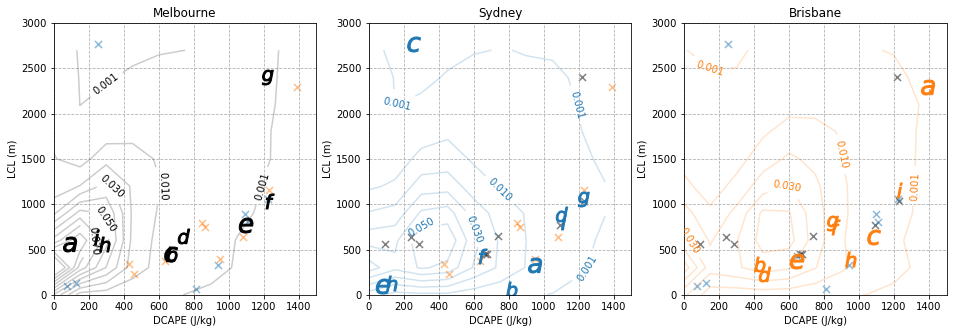

In [227]:
plt.figure(figsize=[16,5])
cnt=1
letter = ["a","b","c","d","e","f","g","h","i"]
letter_cols = ["k","tab:blue","tab:orange"]
locs = ["Melbourne", "Sydney", "Amberley"]
titles = ["Melbourne", "Sydney", "Brisbane"]
for details in (details_list):
    ax=plt.subplot(1,3,cnt)
    
    dcape = df_list[cnt-1]["dcape"].values
    lcl = df_list[cnt-1]["lcl"].values    
    for i in np.arange(len(dcape)):
            plt.plot(dcape[i],lcl[i],marker="$"+letter[i]+"$",ls="none",color=letter_cols[cnt-1],ms=15,mew=1)

    cnt2=0
    for df in df_list:
        if cnt2==(cnt-1):
            pass
        else:
            dcape = df["dcape"].values
            lcl = df["lcl"].values    
            plt.scatter(dcape,lcl,color=letter_cols[cnt2],alpha=0.5,s=50,marker="x")
        cnt2=cnt2+1
            
    plt.xlabel("DCAPE (J/kg)")
    plt.ylabel("LCL (m)")
    plt.gca().grid(ls="--")

    # plt.yscale("symlog")
    plt.ylim([0,3000])
    plt.xlim([0,1500])

    #CLIM PLOT
    c_levels = np.insert(np.arange(0,0.11,0.01), 1, [0.001])
    H, xe, ye = np.histogram2d(clim[clim.loc_id==locs[cnt-1]].dcape.values, clim[clim.loc_id==locs[cnt-1]].mu_lcl.values, 
                           bins=[ np.arange(-75,1575,150), np.arange(-150,3150,300)])
    x,y = np.meshgrid(([(xe[i] + xe[i+1])/2. for i in np.arange(len(xe)-1)]), ([(ye[i] + ye[i+1])/2. for i in np.arange(len(ye)-1)]))
    c=plt.contour(x,y,H.T/(H.sum()), colors=letter_cols[cnt-1] ,alpha=0.2, levels=c_levels)
    labs = plt.clabel(c, c_levels[0:-1:2])
    [l.set_alpha(1) for l in labs]
    labs = plt.clabel(c, [c_levels[1]])
    [l.set_alpha(1) for l in labs]
    
#     ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(subs="all"))
    
    plt.title(titles[cnt-1])
    
    cnt=cnt+1    

In [148]:
H, xe, ye = np.histogram2d(clim[clim.loc_id=="Melbourne"].s06.values, clim[clim.loc_id=="Melbourne"].mu_cape.values, 
                           bins=[ np.arange(-5,55,5), np.concatenate([[-1],np.logspace(0,4,num=10)])])
x,y = np.meshgrid(([(xe[i] + xe[i+1])/2. for i in np.arange(len(xe)-1)]), ([(ye[i] + ye[i+1])/2. for i in np.arange(len(ye)-1)]))

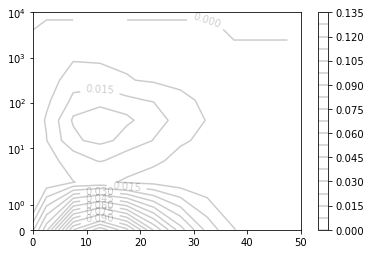

In [172]:
c=plt.contour(x,y,H.T/(H.sum()), levels=np.arange(0,0.135,0.0075), colors="k",alpha=0.2)
plt.yscale("symlog")
plt.ylim([0,10000])
plt.xlim([0,50])
plt.colorbar()
labs = plt.clabel(c, np.arange(0,0.135,0.0075)[0:-1:2])

In [228]:
np.insert(np.arange(0,0.13,0.01), 1, [0.001])

array([0.   , 0.001, 0.01 , 0.02 , 0.03 , 0.04 , 0.05 , 0.06 , 0.07 ,
       0.08 , 0.09 , 0.1  , 0.11 , 0.12 ])

In [182]:
plt.hist(

array([6796.9068319, 6796.9068319, 6796.9068319, 6796.9068319,
       6796.9068319, 6796.9068319, 6796.9068319, 6796.9068319,
       6796.9068319, 6796.9068319, 6796.9068319])

In [161]:
plt.contour?

Signature: plt.contour(*args, data=None, **kwargs)
Docstring:
Plot contours.

Call signature::

    contour([X, Y,] Z, [levels], **kwargs)

`.contour` and `.contourf` draw contour lines and filled contours,
respectively.  Except as noted, function signatures and return values
are the same for both versions.

Parameters
----------
X, Y : array-like, optional
    The coordinates of the values in *Z*.

    *X* and *Y* must both be 2-D with the same shape as *Z* (e.g.
    created via `numpy.meshgrid`), or they must both be 1-D such
    that ``len(X) == M`` is the number of columns in *Z* and
    ``len(Y) == N`` is the number of rows in *Z*.

    If not given, they are assumed to be integer indices, i.e.
    ``X = range(M)``, ``Y = range(N)``.

Z : array-like(N, M)
    The height values over which the contour is drawn.

levels : int or array-like, optional
    Determines the number and positions of the contour lines / regions.

    If an int *n*, use *n* data intervals; i.e. draw *n+1* cont